# Segmentasi Daun dengan U-Net EfficientNet-B0

Digunakan untuk melatih model segmentasi daun menggunakan arsitektur U-Net dengan encoder EfficientNet-B0 pretrained ImageNet.

Model dilatih untuk menghasilkan mask daun dari citra input, sehingga area daun dapat dipisahkan dari background sebelum digunakan pada tahap segmentasi lesi dan klasifikasi penyakit.

Tahapan utama yang dilakukan dalam notebook ini meliputi preprocessing citra, augmentasi data, pembuatan dataset dan dataloader, pelatihan model, evaluasi performa, serta penyimpanan model terbaik.

Proses training dilakukan dalam dua tahap:

*   Stage 1: encoder dibekukan, hanya decoder dan segmentation head yang dilatih.
*   Stage 2: seluruh layer dibuka kembali untuk fine-tuning dengan learning rate yang lebih kecil.

Model terbaik dipilih berdasarkan performa validasi dan digunakan sebagai model segmentasi daun pada sistem akhir.

## 1. Install dan import library

In [ ]:
!pip -q install segmentation-models-pytorch albumentations opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.6 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
import time
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from google.colab import drive, files

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch: 2.11.0+cu128
CUDA available: True


## 2. Mount Drive dan konfigurasi

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_DIR = Path('/content/drive/MyDrive/SkripsiFinal/grape_disease_project/dataset_segmentasi_daun')
MODEL_DIR = Path('/content/drive/MyDrive/SkripsiFinal/models/model_segmentasi_daun_efficientnetb0')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'model_segmentasi_daun_efficientnetb0'

MODEL_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_best.pth'
LAST_MODEL_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_last.pth'
CONFIG_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_config.json'
CURVE_SAVE_PATH = MODEL_DIR / f'{MODEL_NAME}_training_curves.png'
THRESHOLD_SWEEP_CSV = MODEL_DIR / f'{MODEL_NAME}_threshold_sweep_val.csv'
TEST_EVAL_CSV = MODEL_DIR / f'{MODEL_NAME}_test_eval.csv'

In [ ]:
ARCHITECTURE = 'Unet'
ENCODER_NAME = 'efficientnet-b0'
ENCODER_WEIGHTS = 'imagenet'

IMG_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42

STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 30
LR_STAGE1 = 1e-4
LR_STAGE2 = 1e-5
WEIGHT_DECAY = 5e-4
EARLY_STOPPING_PATIENCE = 8
SCHEDULER_PATIENCE = 3
THRESHOLD = 0.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## 3. Cek dataset dan exact duplicate antar split

In [ ]:
IMAGE_EXTS = ['.jpg', '.jpeg', '.png', '.webp']
SPLITS = ['train', 'val', 'test']


def list_images(split_dir):
    return sorted([
        p for p in split_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTS
        and not p.stem.endswith('_mask')
    ])


def find_mask(img_path):
    for ext in IMAGE_EXTS:
        mask_path = img_path.parent / f'{img_path.stem}_mask{ext}'
        if mask_path.exists():
            return mask_path
    return None


def check_dataset(dataset_dir):
    rows = []
    issues = []

    for split in SPLITS:
        split_dir = dataset_dir / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Folder tidak ditemukan: {split_dir}')

        images = list_images(split_dir)

        for img_path in images:
            mask_path = find_mask(img_path)

            if mask_path is None:
                issues.append([split, img_path.name, 'mask tidak ditemukan'])
                continue

            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

            if mask is None:
                issues.append([split, img_path.name, 'mask tidak dapat dibaca'])
                continue

            mask_bin = (mask > 0).astype(np.uint8)
            coverage = mask_bin.mean() * 100

            if coverage < 1 or coverage > 98:
                issues.append([split, img_path.name, f'coverage tidak normal: {coverage:.2f}%'])

            rows.append({
                'split': split,
                'image': img_path.name,
                'mask': mask_path.name,
                'mask_coverage_pct': coverage
            })

    data_df = pd.DataFrame(rows)
    issue_df = pd.DataFrame(issues, columns=['split', 'file', 'keterangan'])

    return data_df, issue_df

In [ ]:
data_df, issue_df = check_dataset(DATASET_DIR)

summary_df = data_df.groupby('split').agg(
    jumlah_data=('image', 'count'),
    rata_rata_coverage=('mask_coverage_pct', 'mean'),
    min_coverage=('mask_coverage_pct', 'min'),
    max_coverage=('mask_coverage_pct', 'max')
).round(2)

display(summary_df)

if len(issue_df) > 0:
    display(issue_df.head(20))
else:
    print('Dataset aman untuk digunakan.')

,jumlah_data,rata_rata_coverage,min_coverage,max_coverage
split,,,,
test,88,46.46,25.77,65.54
train,399,45.96,16.01,68.19
val,84,46.66,18.98,65.37


Dataset aman untuk digunakan.


In [ ]:
import hashlib


def file_hash(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()

    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            md5.update(chunk)

    return md5.hexdigest()


def check_duplicate_images(dataset_dir):
    rows = []

    for split in SPLITS:
        split_dir = dataset_dir / split

        for img_path in list_images(split_dir):
            rows.append({
                'split': split,
                'file': img_path.name,
                'path': str(img_path),
                'hash': file_hash(img_path)
            })

    hash_df = pd.DataFrame(rows)

    duplicate_df = hash_df[
        hash_df.duplicated('hash', keep=False)
    ].sort_values(['hash', 'split', 'file'])

    cross_split_df = duplicate_df.groupby('hash').filter(
        lambda x: x['split'].nunique() > 1
    )

    summary = pd.DataFrame({
        'jumlah_gambar': [len(hash_df)],
        'jumlah_duplicate': [len(duplicate_df)],
        'duplicate_lintas_split': [cross_split_df['hash'].nunique()]
    })

    display(summary)

    if len(cross_split_df) > 0:
        display(cross_split_df)
        raise ValueError('Ditemukan duplicate image lintas split.')

    if len(duplicate_df) > 0:
        display(duplicate_df.head(20))
    else:
        print('Tidak ditemukan exact duplicate image.')

    return hash_df, duplicate_df, cross_split_df


image_hash_df, duplicate_df, cross_split_df = check_duplicate_images(DATASET_DIR)

,jumlah_gambar,jumlah_duplicate,duplicate_lintas_split
0,571,0,0


Tidak ditemukan exact duplicate image.


## 4. Preprocessing

Citra diubah ke ukuran 256×256 menggunakan letterbox agar rasio gambar tetap terjaga. Area kosong pada citra diisi putih, sedangkan area kosong pada mask diisi 0.

In [ ]:
def letterbox_resize(image, mask=None, size=IMG_SIZE, image_pad=255):
    h, w = image.shape[:2]

    scale = min(size / w, size / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    image_canvas = np.full((size, size, 3), image_pad, dtype=np.uint8)

    top = (size - new_h) // 2
    left = (size - new_w) // 2

    image_canvas[top:top + new_h, left:left + new_w] = resized_image

    if mask is None:
        return image_canvas

    resized_mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    mask_canvas = np.zeros((size, size), dtype=np.uint8)
    mask_canvas[top:top + new_h, left:left + new_w] = resized_mask

    return image_canvas, mask_canvas


class LetterboxPad:
    def __init__(self, size=IMG_SIZE, image_pad=255):
        self.size = size
        self.image_pad = image_pad

    def __call__(self, image, mask=None):
        if mask is None:
            image = letterbox_resize(image, size=self.size, image_pad=self.image_pad)
            return {'image': image}

        image, mask = letterbox_resize(
            image,
            mask,
            size=self.size,
            image_pad=self.image_pad
        )

        return {'image': image, 'mask': mask}

## 5. Augmentasi

Augmentasi digunakan pada data training untuk menambah variasi citra tanpa mengubah pasangan gambar dan mask. Data validasi hanya dinormalisasi agar evaluasi tetap konsisten.

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),

    A.HueSaturationValue(
        hue_shift_limit=8,
        sat_shift_limit=12,
        val_shift_limit=8,
        p=0.25
    ),

    A.RandomGamma(
        gamma_limit=(85, 115),
        p=0.2
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),

    A.Affine(
        scale=(0.97, 1.03),
        translate_percent=(-0.02, 0.02),
        rotate=(-8, 8),
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        border_mode=cv2.BORDER_CONSTANT,
        fill=(255, 255, 255),
        fill_mask=0,
        p=0.2
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])


val_transform = A.Compose([
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

## 6. Dataset dan DataLoader

In [ ]:
class LeafSegmentationDataset(Dataset):
    def __init__(self, dataset_dir, split, transform=None, size=IMG_SIZE):
        self.split_dir = Path(dataset_dir) / split
        self.transform = transform
        self.size = size

        self.images = [
            img_path for img_path in list_images(self.split_dir)
            if find_mask(img_path) is not None
        ]

        if len(self.images) == 0:
            raise ValueError(f'Tidak ada data valid di {self.split_dir}')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = find_mask(img_path)

        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        image, mask = letterbox_resize(image, mask, size=self.size, image_pad=255)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).float()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3:
            mask = mask.permute(2, 0, 1)

        return image.float(), mask.float(), img_path.name

In [ ]:
train_dataset = LeafSegmentationDataset(DATASET_DIR, 'train', transform=train_transform)
val_dataset = LeafSegmentationDataset(DATASET_DIR, 'val', transform=val_transform)
test_dataset = LeafSegmentationDataset(DATASET_DIR, 'test', transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
loader_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'jumlah_data': [len(train_dataset), len(val_dataset), len(test_dataset)],
    'jumlah_batch': [len(train_loader), len(val_loader), len(test_loader)]
})

display(loader_summary)

,split,jumlah_data,jumlah_batch
0,train,399,25
1,val,84,6
2,test,88,6


## 7. Model, loss, metrics

In [ ]:
def build_model():
    return smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None
    )


model = build_model().to(DEVICE)

model_info = pd.DataFrame({
    'parameter': ['architecture', 'encoder', 'encoder_weights', 'input_channel', 'output_channel'],
    'value': ['U-Net', ENCODER_NAME, ENCODER_WEIGHTS, 3, 1]
})

display(model_info)

,parameter,value
0,architecture,U-Net
1,encoder,efficientnet-b0
2,encoder_weights,imagenet
3,input_channel,3
4,output_channel,1


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.reshape(probs.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )

        return 1 - dice.mean()


class ComboLoss(nn.Module):
    def __init__(self, bce_weight=0.4, dice_weight=0.6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


criterion = ComboLoss(bce_weight=0.4, dice_weight=0.6)

In [ ]:
def calculate_metrics(logits, targets, threshold=THRESHOLD, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = (targets > 0.5).float()

    preds = preds.reshape(preds.size(0), -1)
    targets = targets.reshape(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    dice = ((2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)).mean()
    iou = ((intersection + eps) / (union + eps)).mean()
    acc = (preds == targets).float().mean()

    return {
        'dice': dice.item(),
        'iou': iou.item(),
        'accuracy': acc.item()
    }

## 8. Freeze/unfreeze utilities

In [ ]:
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

freeze_encoder(model)

## 9. Training loop

In [ ]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0
    total_acc = 0

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, masks, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, masks)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            metrics = calculate_metrics(logits.detach(), masks.detach())

            total_loss += loss.item()
            total_dice += metrics['dice']
            total_iou += metrics['iou']
            total_acc += metrics['accuracy']

    n = len(loader)

    return {
        'loss': total_loss / n,
        'dice': total_dice / n,
        'iou': total_iou / n,
        'acc': total_acc / n
    }

In [ ]:
def save_model(model, optimizer, epoch, stage, val_dice, history, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
        'stage': stage,
        'val_dice': val_dice,
        'history': history,
        'config': {
            'model_name': MODEL_NAME,
            'img_size': IMG_SIZE,
            'threshold': THRESHOLD,
            'architecture': ARCHITECTURE,
            'encoder': ENCODER_NAME,
            'preprocessing': 'letterbox_white_padding'
        }
    }, path)

In [ ]:
def train_stage(model, stage, epochs, lr, mode, start_epoch, best_dice, history):
    if mode == 'freeze':
        freeze_encoder(model)
    elif mode == 'unfreeze':
        unfreeze_all(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=SCHEDULER_PATIENCE
    )

    stop_count = 0
    epoch = start_epoch

    for _ in range(epochs):
        epoch += 1

        train_result = run_epoch(model, train_loader, optimizer)
        val_result = run_epoch(model, val_loader)

        scheduler.step(val_result['dice'])

        row = {
            'epoch': epoch,
            'stage': stage,
            'lr': optimizer.param_groups[0]['lr'],
            'train_loss': train_result['loss'],
            'train_dice': train_result['dice'],
            'train_iou': train_result['iou'],
            'val_loss': val_result['loss'],
            'val_dice': val_result['dice'],
            'val_iou': val_result['iou']
        }

        history.append(row)

        is_best = val_result['dice'] > best_dice

        if is_best:
            best_dice = val_result['dice']
            stop_count = 0
            save_model(model, optimizer, epoch, stage, best_dice, history, MODEL_SAVE_PATH)
        else:
            stop_count += 1

        print(
            f"Epoch {epoch:02d} | {stage} | "
            f"Train Dice {train_result['dice']:.4f} | "
            f"Val Dice {val_result['dice']:.4f} | "
            f"Val IoU {val_result['iou']:.4f}"
        )

        if stop_count >= EARLY_STOPPING_PATIENCE:
            break

    return epoch, best_dice, history

## 10. Training Model

In [ ]:
history = []
best_val_dice = -1
epoch = 0

epoch, best_val_dice, history = train_stage(
    model=model,
    stage='stage_1',
    epochs=STAGE1_EPOCHS,
    lr=LR_STAGE1,
    mode='freeze',
    start_epoch=epoch,
    best_dice=best_val_dice,
    history=history
)

epoch, best_val_dice, history = train_stage(
    model=model,
    stage='stage_2',
    epochs=STAGE2_EPOCHS,
    lr=LR_STAGE2,
    mode='unfreeze',
    start_epoch=epoch,
    best_dice=best_val_dice,
    history=history
)

torch.save({
    'model_state_dict': model.state_dict(),
    'epoch': epoch,
    'best_val_dice': best_val_dice,
    'history': history,
    'config': {
        'model_name': MODEL_NAME,
        'img_size': IMG_SIZE,
        'threshold': THRESHOLD,
        'architecture': ARCHITECTURE,
        'encoder': ENCODER_NAME,
        'preprocessing': 'letterbox_white_padding'
    }
}, LAST_MODEL_SAVE_PATH)

print(f'Training selesai. Best Val Dice: {best_val_dice:.4f}')

Epoch 01 | stage_1 | Train Dice 0.6265 | Val Dice 0.8396 | Val IoU 0.7309
Epoch 02 | stage_1 | Train Dice 0.8736 | Val Dice 0.9107 | Val IoU 0.8459
Epoch 03 | stage_1 | Train Dice 0.9317 | Val Dice 0.9399 | Val IoU 0.8951
Epoch 04 | stage_1 | Train Dice 0.9571 | Val Dice 0.9593 | Val IoU 0.9259
Epoch 05 | stage_1 | Train Dice 0.9674 | Val Dice 0.9653 | Val IoU 0.9353
Epoch 06 | stage_1 | Train Dice 0.9723 | Val Dice 0.9732 | Val IoU 0.9489
Epoch 07 | stage_1 | Train Dice 0.9749 | Val Dice 0.9739 | Val IoU 0.9500
Epoch 08 | stage_1 | Train Dice 0.9766 | Val Dice 0.9777 | Val IoU 0.9570
Epoch 09 | stage_1 | Train Dice 0.9778 | Val Dice 0.9775 | Val IoU 0.9567
Epoch 10 | stage_1 | Train Dice 0.9783 | Val Dice 0.9794 | Val IoU 0.9601
Epoch 11 | stage_2 | Train Dice 0.9794 | Val Dice 0.9799 | Val IoU 0.9611
Epoch 12 | stage_2 | Train Dice 0.9802 | Val Dice 0.9800 | Val IoU 0.9613
Epoch 13 | stage_2 | Train Dice 0.9797 | Val Dice 0.9802 | Val IoU 0.9617
Epoch 14 | stage_2 | Train Dice 0.9804

## 11. Plot training curve

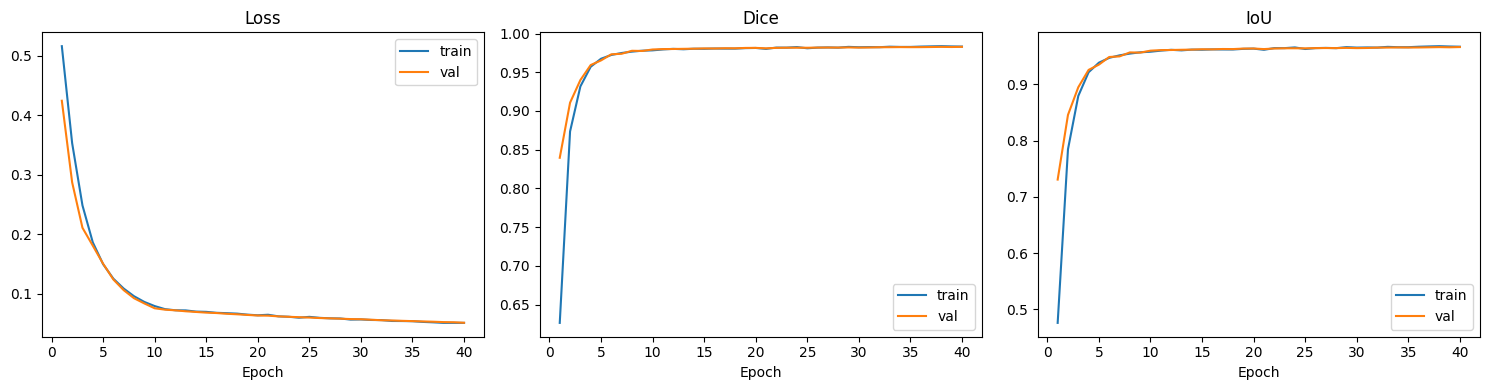

In [ ]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['train_dice'], label='train')
axes[1].plot(hist_df['epoch'], hist_df['val_dice'], label='val')
axes[1].set_title('Dice')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(hist_df['epoch'], hist_df['train_iou'], label='train')
axes[2].plot(hist_df['epoch'], hist_df['val_iou'], label='val')
axes[2].set_title('IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(CURVE_SAVE_PATH, dpi=200, bbox_inches='tight')
plt.show()

## 12. Threshold Validation

Threshold terbaik dipilih dari data validasi. Nilai threshold dipilih berdasarkan Dice tertinggi, dengan tetap memperhatikan recall agar area daun tidak mudah terpotong.

In [ ]:
def mask_metrics(pred, target, eps=1e-6):
    pred = (pred > 0).astype(np.uint8)
    target = (target > 0).astype(np.uint8)

    tp = np.logical_and(pred == 1, target == 1).sum()
    fp = np.logical_and(pred == 1, target == 0).sum()
    fn = np.logical_and(pred == 0, target == 1).sum()

    dice = (2 * tp + eps) / (pred.sum() + target.sum() + eps)
    iou = (tp + eps) / (np.logical_or(pred, target).sum() + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return dice, iou, precision, recall


def get_predictions(model, loader):
    probs_all = []
    masks_all = []

    model.eval()

    with torch.no_grad():
        for images, masks, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images)

            probs = torch.sigmoid(logits).cpu().numpy()[:, 0]
            masks = masks.cpu().numpy()[:, 0]

            probs_all.extend(probs)
            masks_all.extend(masks)

    return probs_all, masks_all

In [ ]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)

model = build_model().to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

val_probs, val_masks = get_predictions(model, val_loader)

thresholds = np.arange(0.30, 0.71, 0.05)
rows = []

for threshold in thresholds:
    scores = []

    for prob, mask in zip(val_probs, val_masks):
        pred = prob >= threshold
        target = mask > 0.5

        dice, iou, precision, recall = mask_metrics(pred, target)

        scores.append({
            'dice': dice,
            'iou': iou,
            'precision': precision,
            'recall': recall
        })

    score_df = pd.DataFrame(scores)

    rows.append({
        'threshold': round(float(threshold), 2),
        'dice': score_df['dice'].mean(),
        'iou': score_df['iou'].mean(),
        'precision': score_df['precision'].mean(),
        'recall': score_df['recall'].mean()
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(THRESHOLD_SWEEP_CSV, index=False)

display(threshold_df)

,threshold,dice,iou,precision,recall
0,0.30,0.982032,0.964993,0.971666,0.992843
1,0.35,0.982949,0.966761,0.974503,0.991753
2,0.40,0.983684,0.968184,0.977027,0.990638
3,0.45,0.984191,0.969166,0.979280,0.989350
4,0.50,0.984553,0.969870,0.981354,0.987968
5,0.55,0.984739,0.970234,0.983294,0.986380
6,0.60,0.984694,0.970149,0.985082,0.984497
7,0.65,0.984441,0.969665,0.986756,0.982329
8,0.70,0.983944,0.968707,0.988428,0.979697


In [ ]:
best_dice = threshold_df['dice'].max()
candidate_df = threshold_df[threshold_df['dice'] >= best_dice - 0.002]

selected = candidate_df.sort_values(
    ['recall', 'dice'],
    ascending=False
).iloc[0]

THRESHOLD = float(selected['threshold'])

print(f'Selected threshold: {THRESHOLD}')

Selected threshold: 0.35


## 13. Evaluasi Test

In [ ]:
def score_mask(pred, target, eps=1e-6):
    pred = (pred > 0).astype(np.uint8)
    target = (target > 0).astype(np.uint8)

    tp = np.logical_and(pred == 1, target == 1).sum()
    fp = np.logical_and(pred == 1, target == 0).sum()
    fn = np.logical_and(pred == 0, target == 1).sum()
    tn = np.logical_and(pred == 0, target == 0).sum()

    dice = (2 * tp + eps) / (pred.sum() + target.sum() + eps)
    iou = (tp + eps) / (np.logical_or(pred, target).sum() + eps)
    acc = (tp + tn + eps) / (tp + tn + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return dice, iou, acc, precision, recall

In [ ]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)

model = build_model().to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
_ = model.eval()

print(f"Best model loaded. Epoch: {checkpoint['epoch']}")
print(f"Threshold: {THRESHOLD}")

Best model loaded. Epoch: 40
Threshold: 0.35


In [ ]:
def evaluate_test(model, loader):
    rows = []

    with torch.no_grad():
        for images, masks, names in loader:
            images = images.to(DEVICE, non_blocking=True)

            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()[:, 0]
            masks = masks.cpu().numpy()[:, 0]

            for prob, mask, name in zip(probs, masks, names):
                pred = prob >= THRESHOLD
                target = mask > 0.5

                dice, iou, acc, precision, recall = score_mask(pred, target)

                rows.append({
                    'file': name,
                    'dice': dice,
                    'iou': iou,
                    'accuracy': acc,
                    'precision': precision,
                    'recall': recall
                })

    return pd.DataFrame(rows)


test_df = evaluate_test(model, test_loader)
test_df.to_csv(TEST_EVAL_CSV, index=False)

result_df = test_df[['dice', 'iou', 'accuracy', 'precision', 'recall']].agg(['mean', 'std']).round(4)

display(result_df)

,dice,iou,accuracy,precision,recall
mean,0.9808,0.9628,0.9834,0.9719,0.9903
std,0.0152,0.0283,0.0107,0.0259,0.0093


## 14. Simpan config

In [ ]:
config = {
    'model_name': MODEL_NAME,
    'architecture': ARCHITECTURE,
    'encoder': ENCODER_NAME,
    'encoder_weights': ENCODER_WEIGHTS,
    'img_size': IMG_SIZE,
    'preprocessing': 'letterbox_white_padding',
    'threshold': THRESHOLD,
    'batch_size': BATCH_SIZE,
    'stage1_epochs': STAGE1_EPOCHS,
    'stage2_epochs': STAGE2_EPOCHS,
    'lr_stage1': LR_STAGE1,
    'lr_stage2': LR_STAGE2,
    'weight_decay': WEIGHT_DECAY,
    'train_count': len(train_dataset),
    'val_count': len(val_dataset),
    'test_count': len(test_dataset)
}

with open(CONFIG_SAVE_PATH, 'w') as f:
    json.dump(config, f, indent=4)